In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/log2.csv')
print(df.shape)
print(df.head())

(65532, 12)
   Source Port  Destination Port  NAT Source Port  NAT Destination Port  \
0        57222                53            54587                    53   
1        56258              3389            56258                  3389   
2         6881             50321            43265                 50321   
3        50553              3389            50553                  3389   
4        50002               443            45848                   443   

  Action  Bytes  Bytes Sent  Bytes Received  Packets  Elapsed Time (sec)  \
0  allow    177          94              83        2                  30   
1  allow   4768        1600            3168       19                  17   
2  allow    238         118             120        2                1199   
3  allow   3327        1438            1889       15                  17   
4  allow  25358        6778           18580       31                  16   

   pkts_sent  pkts_received  
0          1              1  
1         10        

In [ ]:
df.isnull().sum()

,0
Source Port,0
Destination Port,0
NAT Source Port,0
NAT Destination Port,0
Action,0
Bytes,0
Bytes Sent,0
Bytes Received,0
Packets,0
Elapsed Time (sec),0


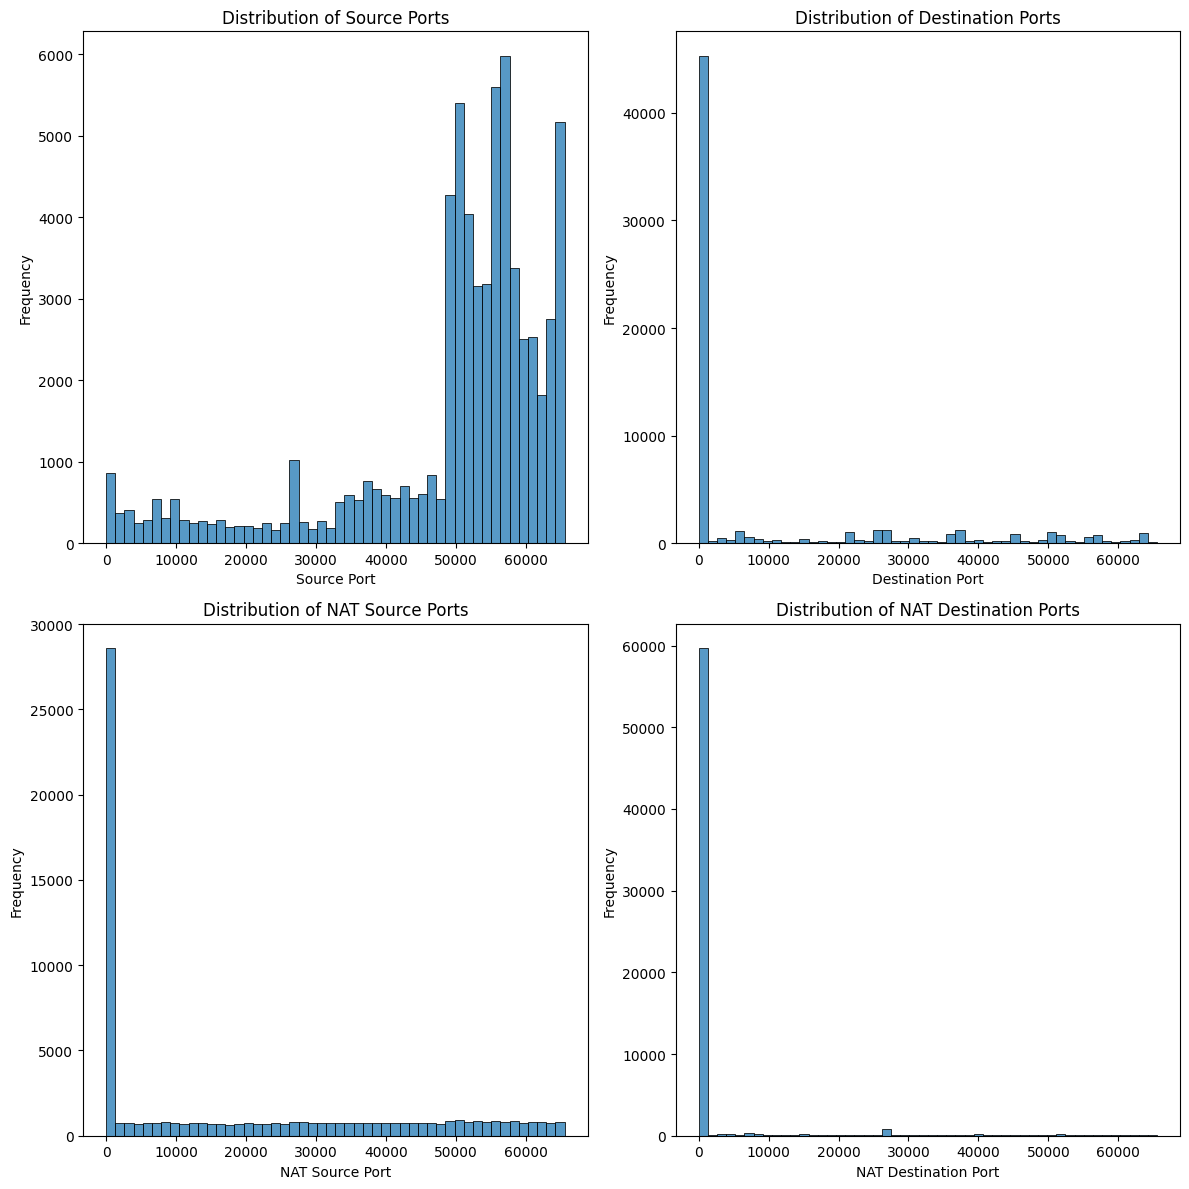

In [ ]:
# ----------------------------------------------------------
# Visualization of Port Distributions
# ----------------------------------------------------------
# This section visualizes the frequency distribution of
# various port-related fields in the dataset to understand
# their overall spread and potential redundancy.
#
# Observations from these plots often reveal that port numbers
# span across a large range with sparse concentration — a key
# reason for excluding them from direct modeling and instead
# applying targeted feature engineering later.
# ----------------------------------------------------------

plt.figure(figsize=(12, 12))

# ----------------------------------------------------------
# Source Port Distribution
# ----------------------------------------------------------
plt.subplot(2, 2, 1)
sns.histplot(df['Source Port'], bins=50, kde=False)
plt.title('Distribution of Source Ports')
plt.xlabel('Source Port')
plt.ylabel('Frequency')

# ----------------------------------------------------------
# Destination Port Distribution
# ----------------------------------------------------------
plt.subplot(2, 2, 2)
sns.histplot(df['Destination Port'], bins=50, kde=False)
plt.title('Distribution of Destination Ports')
plt.xlabel('Destination Port')
plt.ylabel('Frequency')

# ----------------------------------------------------------
# NAT Source Port Distribution
# ----------------------------------------------------------
plt.subplot(2, 2, 3)
sns.histplot(df['NAT Source Port'], bins=50, kde=False)
plt.title('Distribution of NAT Source Ports')
plt.xlabel('NAT Source Port')
plt.ylabel('Frequency')

# ----------------------------------------------------------
# NAT Destination Port Distribution
# ----------------------------------------------------------
plt.subplot(2, 2, 4)
sns.histplot(df['NAT Destination Port'], bins=50, kde=False)
plt.title('Distribution of NAT Destination Ports')
plt.xlabel('NAT Destination Port')
plt.ylabel('Frequency')

# ----------------------------------------------------------
# Final Layout and Display
# ----------------------------------------------------------
plt.tight_layout()
plt.show()

In [ ]:
# ----------------------------------------------------------
# Feature Engineering: Port Matching Indicators
# ----------------------------------------------------------
# The goal here is to create two new binary features that
# indicate whether the normal and NAT port values are identical
# for each record. This helps capture potential relationships
# between NAT translation behavior and connection attributes.
#
# Newly created features:
#   - 'Source_Port_NAT_Match': 1 if Source Port == NAT Source Port, else 0
#   - 'Destination_Port_NAT_Match': 1 if Destination Port == NAT Destination Port, else 0
#
# These derived features can be useful in ML models to identify
# network flow patterns or potential anomalies in NAT behavior.
# ----------------------------------------------------------

df['Source_Port_NAT_Match'] = (df['Source Port'] == df['NAT Source Port']).astype(int)
df['Destination_Port_NAT_Match'] = (df['Destination Port'] == df['NAT Destination Port']).astype(int)

# ----------------------------------------------------------
# Display Updated DataFrame and Shape
# ----------------------------------------------------------
# Verifying that the new columns have been successfully added
# and inspecting the resulting DataFrame dimensions.
# ----------------------------------------------------------
print(df)
print(df.shape)

       Source Port  Destination Port  NAT Source Port  NAT Destination Port  \
0            57222                53            54587                    53   
1            56258              3389            56258                  3389   
2             6881             50321            43265                 50321   
3            50553              3389            50553                  3389   
4            50002               443            45848                   443   
...            ...               ...              ...                   ...   
65527        63691                80            13237                    80   
65528        50964                80            13485                    80   
65529        54871               445                0                     0   
65530        54870               445                0                     0   
65531        54867               445                0                     0   

      Action    Bytes  Bytes Sent  Bytes Received  

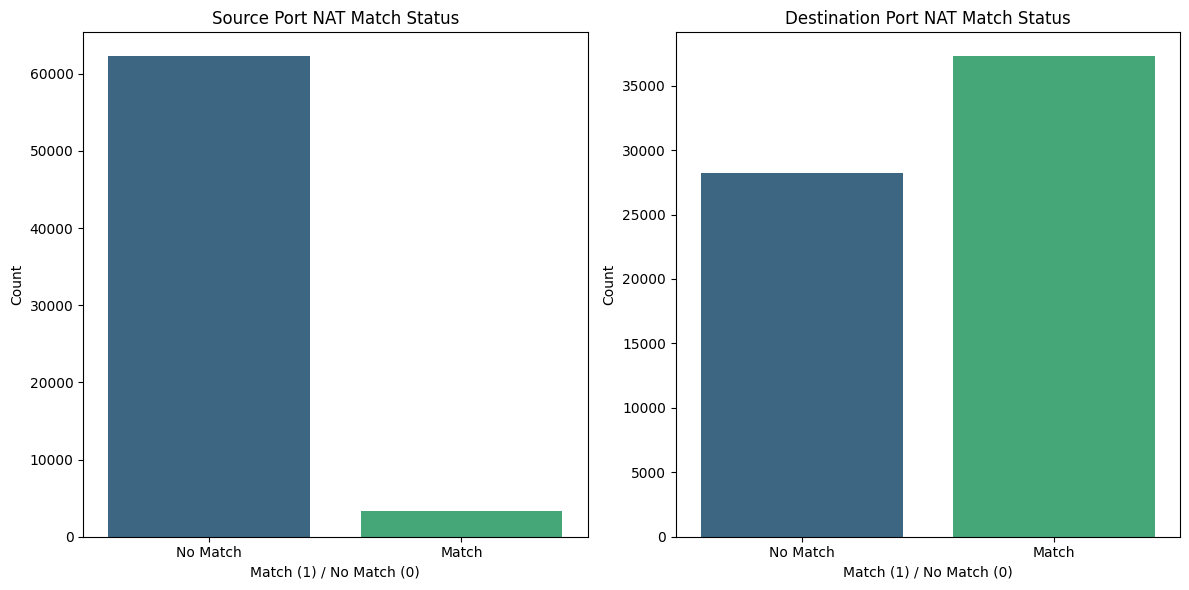

In [ ]:
# ----------------------------------------------------------
# Visualization: NAT Port Match Frequency
# ----------------------------------------------------------
# This visualization illustrates the frequency of matching
# and non-matching port values between:
#   1. Source Port and NAT Source Port
#   2. Destination Port and NAT Destination Port
#
# Objective:
# To observe how often NAT translation retains or modifies
# port numbers. A higher count of "Match" indicates fewer
# NAT changes, while more "No Match" instances suggest
# frequent port remapping by the NAT process.
# ----------------------------------------------------------

plt.figure(figsize=(12, 6))

# ----------------------------------------------------------
# Source Port NAT Match Count Plot
# ----------------------------------------------------------
plt.subplot(1, 2, 1)
sns.countplot(x='Source_Port_NAT_Match', data=df, palette='viridis')
plt.title('Source Port NAT Match Status')
plt.xlabel('Match (1) / No Match (0)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Match', 'Match'])

# ----------------------------------------------------------
# Destination Port NAT Match Count Plot
# ----------------------------------------------------------
plt.subplot(1, 2, 2)
sns.countplot(x='Destination_Port_NAT_Match', data=df, palette='viridis')
plt.title('Destination Port NAT Match Status')
plt.xlabel('Match (1) / No Match (0)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Match', 'Match'])

# ----------------------------------------------------------
# Final Layout and Display
# ----------------------------------------------------------
plt.tight_layout()
plt.show()

In [ ]:
# ----------------------------------------------------------
# Feature Categorization: Categorical vs Numerical
# ----------------------------------------------------------
# Here we explicitly separate categorical and numerical
# features for preprocessing and model preparation.
#
# Reasoning:
#   - Categorical columns: Represent discrete binary indicators
#     (in this case, whether NAT port values matched or not).
#   - Numerical columns: Represent continuous traffic metrics
#     such as byte counts, packet counts, and elapsed time —
#     essential for modeling network flow characteristics.
# ----------------------------------------------------------

categorical_cols = ['Source_Port_NAT_Match', 'Destination_Port_NAT_Match']
numerical_cols = ['Bytes', 'Bytes Sent', 'Bytes Received',
                  'Packets', 'Elapsed Time (sec)',
                  'pkts_sent', 'pkts_received']

# ----------------------------------------------------------
# Display Selected Columns for Verification
# ----------------------------------------------------------
print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['Source_Port_NAT_Match', 'Destination_Port_NAT_Match']
Numerical columns: ['Bytes', 'Bytes Sent', 'Bytes Received', 'Packets', 'Elapsed Time (sec)', 'pkts_sent', 'pkts_received']


In [ ]:
# ----------------------------------------------------------
# Feature Scaling: Normalizing Numerical Features
# ----------------------------------------------------------
# MinMaxScaler is used to scale all numerical columns
# to a uniform range [0, 1].
#
# Why Scaling?
#   - Ensures all features contribute equally to the model.
#   - Prevents large-valued attributes (like Bytes or Packets)
#     from dominating smaller-valued ones (like Elapsed Time).
#   - Improves convergence for gradient-based ML algorithms.
#
# Selected Columns:
#   - 'Bytes', 'Bytes Sent', 'Bytes Received', 'Packets',
#     'Elapsed Time (sec)', 'pkts_sent', 'pkts_received'
# ----------------------------------------------------------

numerical_cols = ['Bytes', 'Bytes Sent', 'Bytes Received',
                  'Packets', 'Elapsed Time (sec)',
                  'pkts_sent', 'pkts_received']

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Fit and transform the numerical columns
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# ----------------------------------------------------------
# Display Transformed Data and Shape
# ----------------------------------------------------------
# Verify that scaling has been applied successfully and
# check the resulting DataFrame structure.
# ----------------------------------------------------------
print(df.head())
print(df.shape)

   Source Port  Destination Port  NAT Source Port  NAT Destination Port  \
0        57222                53            54587                    53   
1        56258              3389            56258                  3389   
2         6881             50321            43265                 50321   
3        50553              3389            50553                  3389   
4        50002               443            45848                   443   

  Action         Bytes    Bytes Sent  Bytes Received       Packets  \
0  allow  9.217251e-08  3.584694e-08    2.586622e-07  9.651438e-07   
1  allow  3.708959e-06  1.623655e-06    9.872794e-06  1.737259e-05   
2  allow  1.402283e-07  6.115066e-08    3.739695e-07  9.651438e-07   
3  allow  2.573740e-06  1.452855e-06    5.886903e-06  1.351201e-05   
4  allow  1.992974e-05  7.082933e-06    5.790294e-05  2.895431e-05   

   Elapsed Time (sec)  pkts_sent  pkts_received  Source_Port_NAT_Match  \
0            0.002772   0.000000       0.000003       

In [ ]:
from sklearn.preprocessing import LabelEncoder

# ----------------------------------------------------------
# Feature Selection & Target Definition
# ----------------------------------------------------------
# Dropping the following columns:
#   - 'Source Port'
#   - 'Destination Port'
#   - 'NAT Source Port'
#   - 'NAT Destination Port'
#
# Reason:
# These port-related fields contain a wide range of unrelated
# or non-informative numerical values that can introduce noise
# into the model. They were later utilized through feature
# engineering to extract more meaningful relationships.
#
# 'Action' column is separated as the target variable.
# ----------------------------------------------------------
X = df.drop(['Action', 'Source Port', 'Destination Port',
             'NAT Source Port', 'NAT Destination Port'], axis=1)
y = df['Action']

# ----------------------------------------------------------
# Label Encoding the Target Variable
# ----------------------------------------------------------
# Since 'Action' is a categorical feature (e.g., ALLOW / DENY),
# we use LabelEncoder to convert it into numerical form for ML models.
# ----------------------------------------------------------
le = LabelEncoder()
y = le.fit_transform(y)

# ----------------------------------------------------------
# Display Processed Features and Encoded Target
# ----------------------------------------------------------
print("Features (X) after preprocessing:")
display(X.head())

print("\nTarget (y) after encoding:")
display(y)

Features (X) after preprocessing:


,Bytes,Bytes Sent,Bytes Received,Packets,Elapsed Time (sec),pkts_sent,pkts_received,Source_Port_NAT_Match,Destination_Port_NAT_Match
0,9.217251e-08,3.584694e-08,2.586622e-07,9.651438e-07,0.002772,0.000000,0.000003,0,1
1,3.708959e-06,1.623655e-06,9.872794e-06,1.737259e-05,0.001571,0.000012,0.000028,1,1
2,1.402283e-07,6.115066e-08,3.739695e-07,9.651438e-07,0.110772,0.000000,0.000003,0,1
3,2.573740e-06,1.452855e-06,5.886903e-06,1.351201e-05,0.001571,0.000009,0.000021,1,1
4,1.992974e-05,7.082933e-06,5.790294e-05,2.895431e-05,0.001478,0.000016,0.000055,0,1



Target (y) after encoding:


array([0, 0, 0, ..., 2, 2, 2])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (52425, 9)
X_test shape: (13107, 9)
y_train shape: (52425,)
y_test shape: (13107,)


In [ ]:
# Display the classes learned by the LabelEncoder
print("Mapping of encoded labels to original classes:")
for i, class_name in enumerate(le.classes_):
    print(f"{i}: {class_name}")

Mapping of encoded labels to original classes:
0: allow
1: deny
2: drop
3: reset-both


Random Forest:
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7545
           1       0.78      1.00      0.88      2994
           2       1.00      0.67      0.80      2562
           3       1.00      0.50      0.67         6

    accuracy                           0.94     13107
   macro avg       0.94      0.79      0.84     13107
weighted avg       0.95      0.94      0.93     13107

Confusion Matrix:
[[7543    2    0    0]
 [   0 2986    8    0]
 [   0  836 1726    0]
 [   0    3    0    3]]
Test Set Accuracy: 93.52%
Cross-Validation Accuracy: 93.30%
Standard Deviation: 0.20%

Feature Importance:


,feature,importance
4,Elapsed Time (sec),0.275897
8,Destination_Port_NAT_Match,0.196933
0,Bytes,0.173432
1,Bytes Sent,0.122913
3,Packets,0.119433
6,pkts_received,0.065950
2,Bytes Received,0.041750
5,pkts_sent,0.002993
7,Source_Port_NAT_Match,0.000699


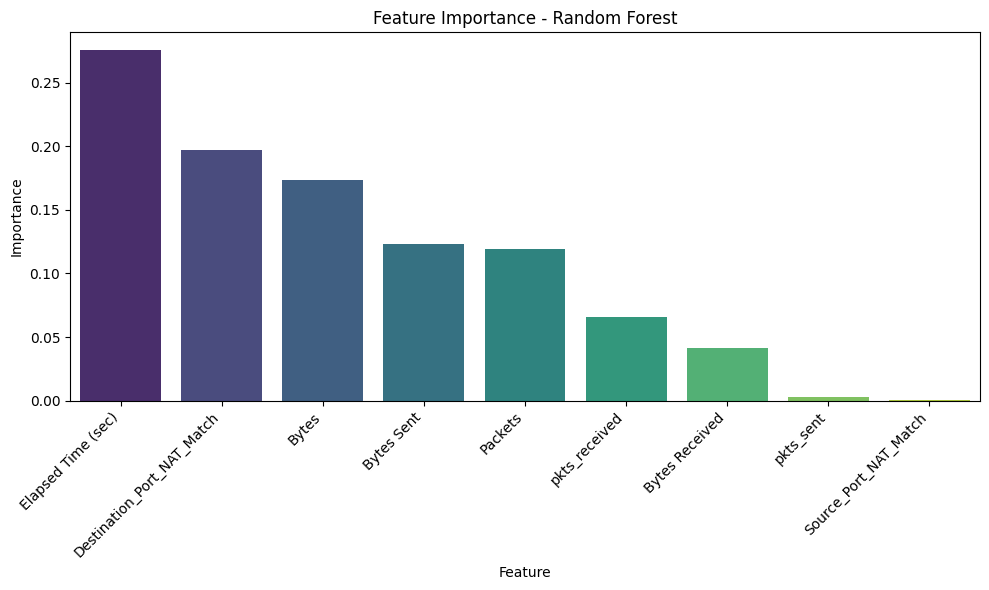

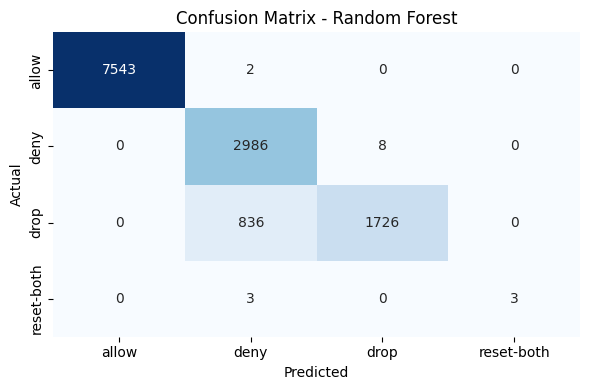


-------------------------------------------------------------

KNN:
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7545
           1       0.78      1.00      0.87      2994
           2       1.00      0.67      0.80      2562
           3       1.00      0.50      0.67         6

    accuracy                           0.93     13107
   macro avg       0.94      0.79      0.84     13107
weighted avg       0.95      0.93      0.93     13107

Confusion Matrix:
[[7545    0    0    0]
 [   6 2980    8    0]
 [   0  836 1726    0]
 [   0    3    0    3]]
Test Set Accuracy: 93.49%
Cross-Validation Accuracy: 93.05%
Standard Deviation: 0.29%


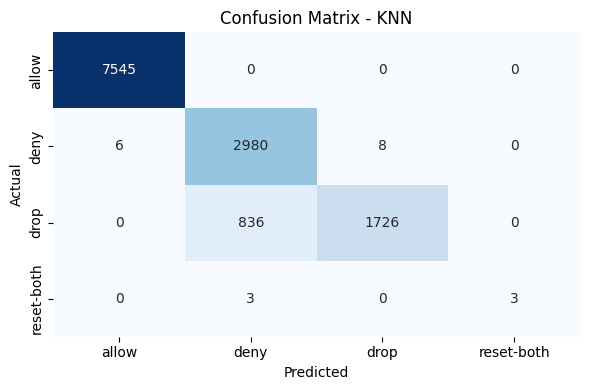


-------------------------------------------------------------

Gradient Boost:
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7545
           1       0.78      1.00      0.88      2994
           2       1.00      0.67      0.80      2562
           3       1.00      0.17      0.29         6

    accuracy                           0.94     13107
   macro avg       0.94      0.71      0.74     13107
weighted avg       0.95      0.94      0.93     13107

Confusion Matrix:
[[7543    2    0    0]
 [   0 2986    8    0]
 [   0  836 1726    0]
 [   0    5    0    1]]
Test Set Accuracy: 93.51%
Cross-Validation Accuracy: 93.29%
Standard Deviation: 0.20%

Feature Importance:


,feature,importance
4,Elapsed Time (sec),0.411589
0,Bytes,0.304613
1,Bytes Sent,0.149442
8,Destination_Port_NAT_Match,0.121910
3,Packets,0.011176
7,Source_Port_NAT_Match,0.000556
2,Bytes Received,0.000538
5,pkts_sent,0.000111
6,pkts_received,0.000065


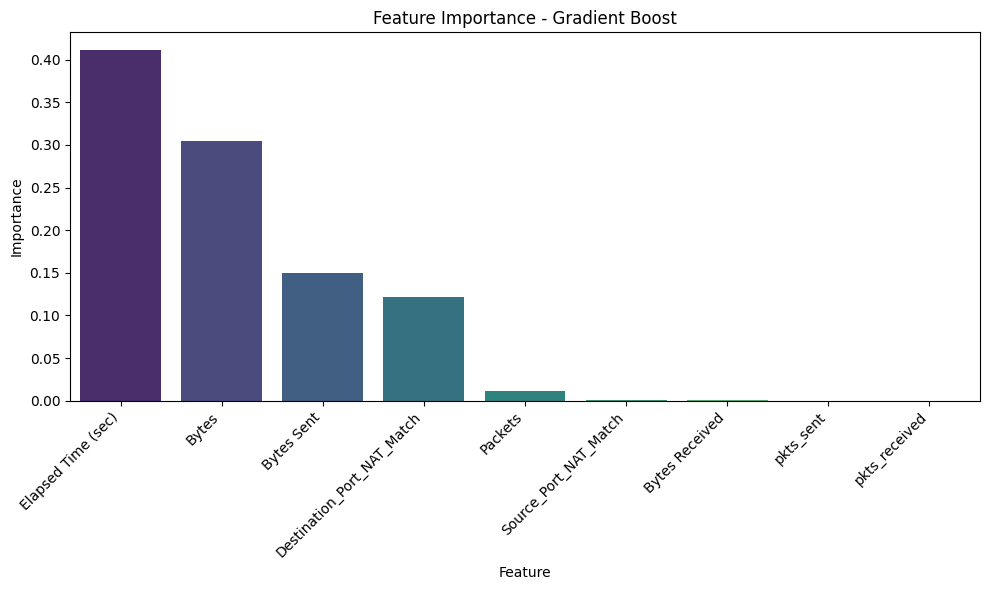

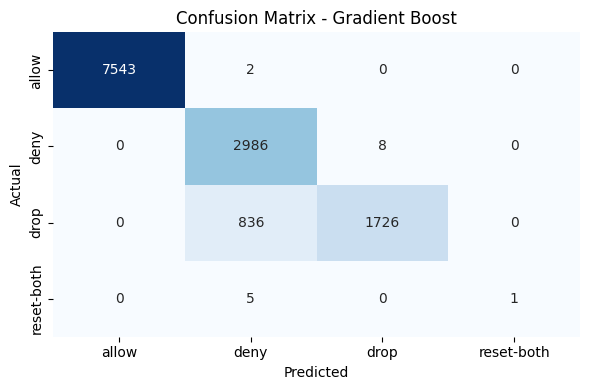


-------------------------------------------------------------

Extra Trees:
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7545
           1       0.78      1.00      0.88      2994
           2       1.00      0.67      0.80      2562
           3       1.00      0.50      0.67         6

    accuracy                           0.94     13107
   macro avg       0.94      0.79      0.84     13107
weighted avg       0.95      0.94      0.93     13107

Confusion Matrix:
[[7543    2    0    0]
 [   0 2986    8    0]
 [   0  836 1726    0]
 [   0    3    0    3]]
Test Set Accuracy: 93.52%
Cross-Validation Accuracy: 93.30%
Standard Deviation: 0.20%

Feature Importance:


,feature,importance
8,Destination_Port_NAT_Match,0.673520
1,Bytes Sent,0.156063
0,Bytes,0.122562
4,Elapsed Time (sec),0.026061
7,Source_Port_NAT_Match,0.011721
2,Bytes Received,0.003132
6,pkts_received,0.003008
3,Packets,0.002736
5,pkts_sent,0.001197


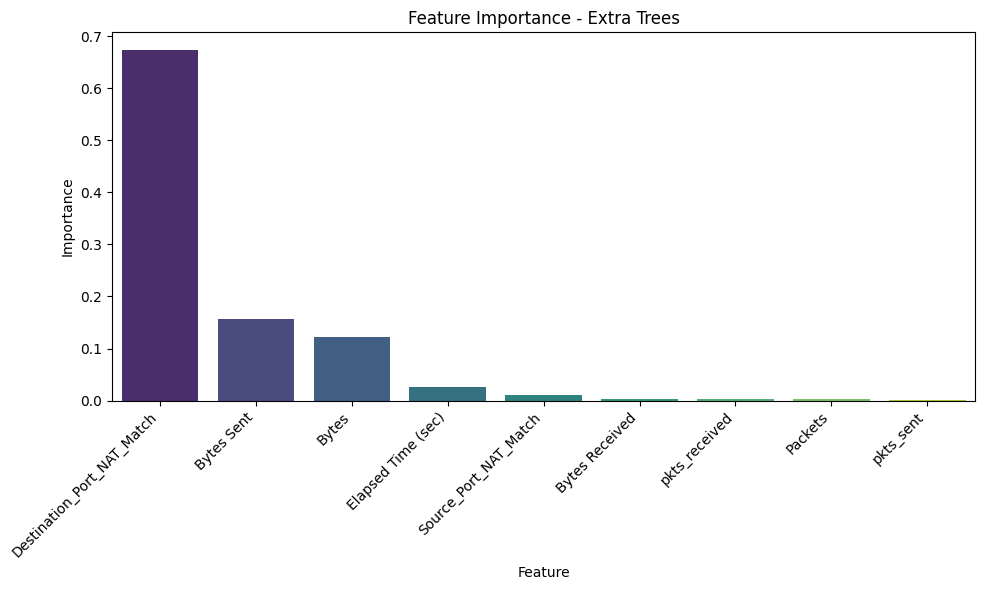

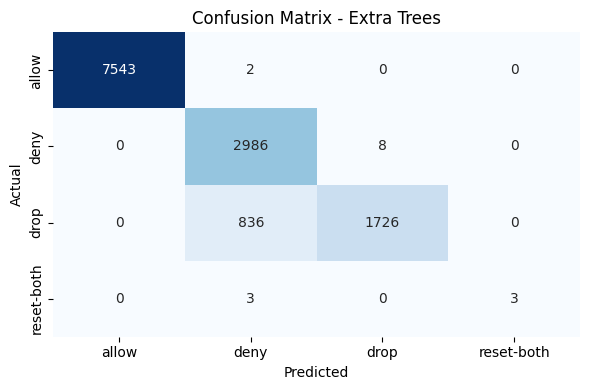


-------------------------------------------------------------

Decision Tree:
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7545
           1       0.78      1.00      0.88      2994
           2       1.00      0.67      0.80      2562
           3       1.00      0.50      0.67         6

    accuracy                           0.94     13107
   macro avg       0.94      0.79      0.84     13107
weighted avg       0.95      0.94      0.93     13107

Confusion Matrix:
[[7543    2    0    0]
 [   0 2986    8    0]
 [   0  836 1726    0]
 [   0    3    0    3]]
Test Set Accuracy: 93.52%
Cross-Validation Accuracy: 93.29%
Standard Deviation: 0.20%

Feature Importance:


,feature,importance
4,Elapsed Time (sec),0.706220
0,Bytes,0.148810
1,Bytes Sent,0.125311
3,Packets,0.018450
7,Source_Port_NAT_Match,0.000991
2,Bytes Received,0.000108
6,pkts_received,0.000107
8,Destination_Port_NAT_Match,0.000002
5,pkts_sent,0.000000


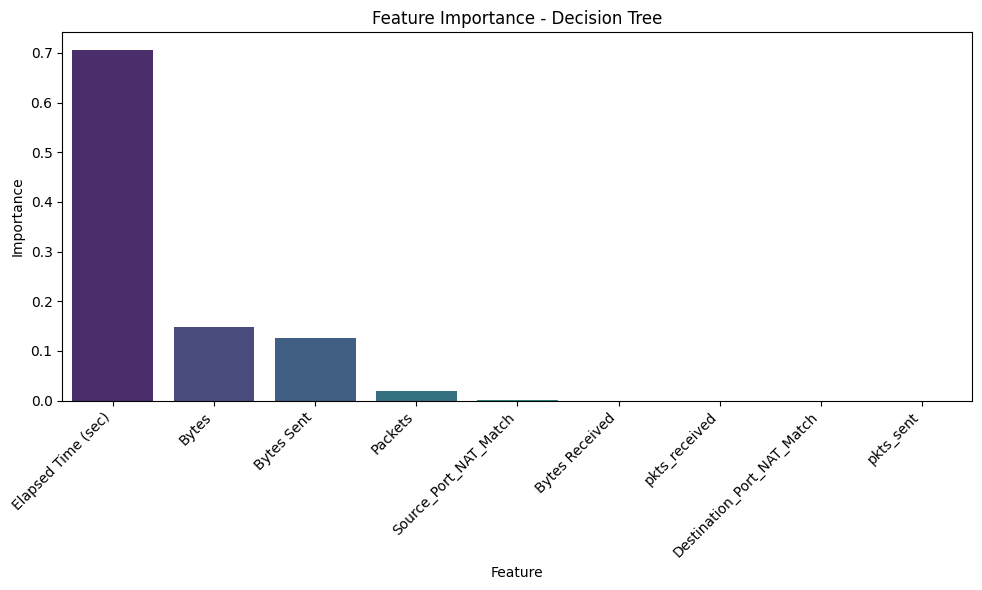

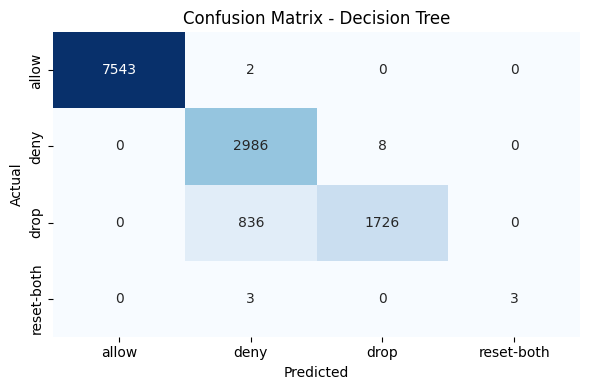


-------------------------------------------------------------

Adaboost:
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7545
           1       1.00      0.67      0.80      2994
           2       0.72      1.00      0.84      2562
           3       0.00      0.00      0.00         6

    accuracy                           0.92     13107
   macro avg       0.68      0.67      0.66     13107
weighted avg       0.94      0.92      0.92     13107

Confusion Matrix:
[[7531    0   14    0]
 [   6 2006  982    0]
 [   0    0 2562    0]
 [   3    3    0    0]]
Test Set Accuracy: 92.31%
Cross-Validation Accuracy: 87.43%
Standard Deviation: 5.93%

Feature Importance:


,feature,importance
0,Bytes,0.338076
4,Elapsed Time (sec),0.311458
1,Bytes Sent,0.147165
8,Destination_Port_NAT_Match,0.101016
3,Packets,0.064437
2,Bytes Received,0.037847
5,pkts_sent,0.000000
6,pkts_received,0.000000
7,Source_Port_NAT_Match,0.000000


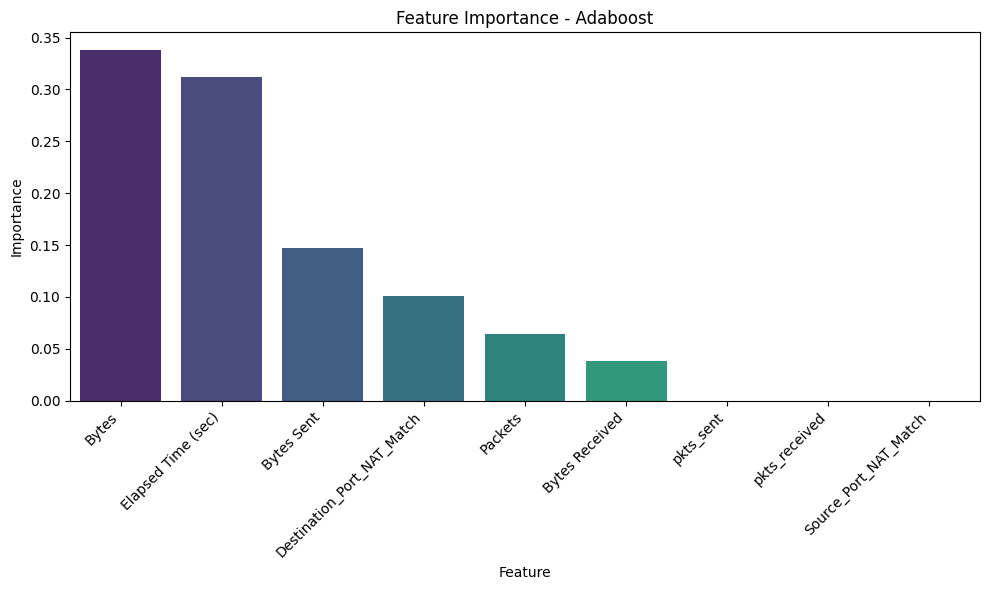

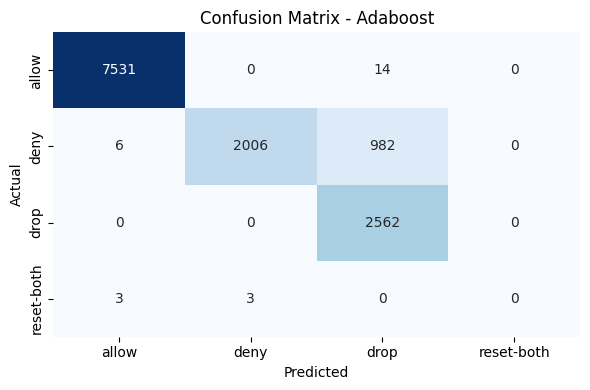


-------------------------------------------------------------

XGboost:
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7545
           1       0.78      0.99      0.87      2994
           2       0.99      0.67      0.80      2562
           3       1.00      0.50      0.67         6

    accuracy                           0.93     13107
   macro avg       0.94      0.79      0.83     13107
weighted avg       0.95      0.93      0.93     13107

Confusion Matrix:
[[7543    2    0    0]
 [   0 2969   25    0]
 [   0  836 1726    0]
 [   0    2    1    3]]
Test Set Accuracy: 93.39%
Cross-Validation Accuracy: 93.19%
Standard Deviation: 0.21%

Feature Importance:


,feature,importance
4,Elapsed Time (sec),0.832289
0,Bytes,0.069231
3,Packets,0.049329
8,Destination_Port_NAT_Match,0.026632
1,Bytes Sent,0.020510
7,Source_Port_NAT_Match,0.001261
5,pkts_sent,0.000329
6,pkts_received,0.000220
2,Bytes Received,0.000199


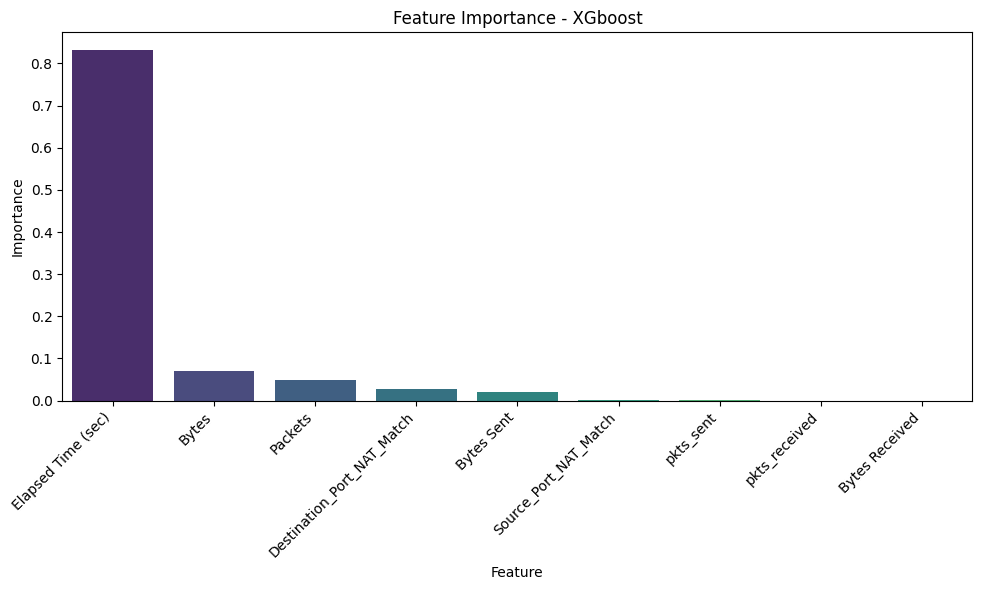

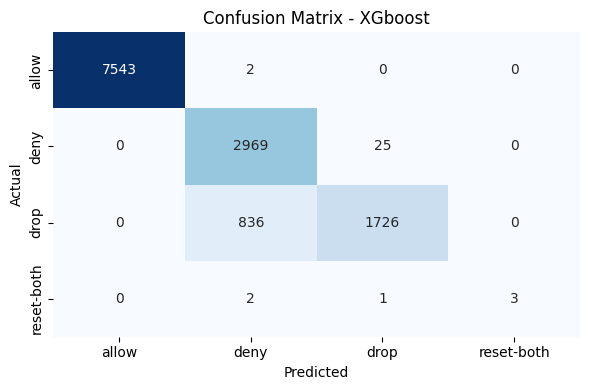


-------------------------------------------------------------

LightGBM:
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7545
           1       0.78      1.00      0.88      2994
           2       0.99      0.67      0.80      2562
           3       1.00      0.50      0.67         6

    accuracy                           0.94     13107
   macro avg       0.94      0.79      0.84     13107
weighted avg       0.95      0.94      0.93     13107

Confusion Matrix:
[[7543    2    0    0]
 [   0 2984   10    0]
 [   0  836 1726    0]
 [   0    3    0    3]]
Test Set Accuracy: 93.51%
Cross-Validation Accuracy: 93.29%
Standard Deviation: 0.20%

Feature Importance:


,feature,importance
0,Bytes,5502
1,Bytes Sent,2411
4,Elapsed Time (sec),1065
2,Bytes Received,505
3,Packets,492
7,Source_Port_NAT_Match,455
8,Destination_Port_NAT_Match,295
5,pkts_sent,168
6,pkts_received,28


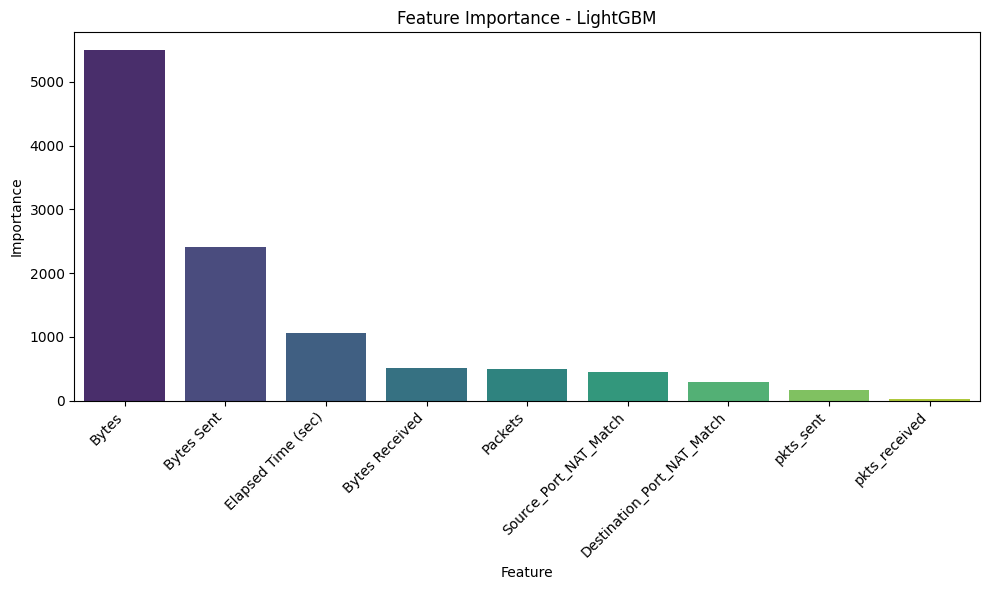

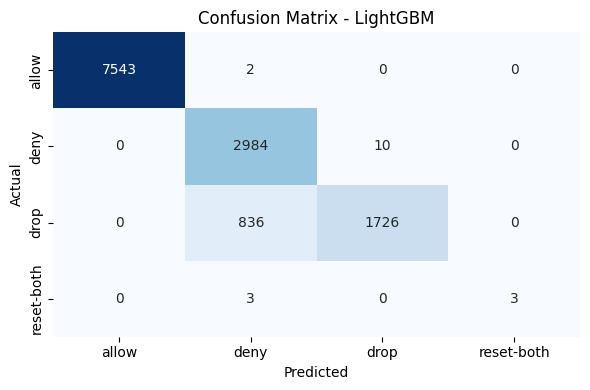


-------------------------------------------------------------



In [ ]:
# ----------------------------------------------------------
# Multi-Model Evaluation: Classification Benchmarking
# ----------------------------------------------------------
# This section trains and evaluates multiple ML classifiers
# on the same dataset to identify the most effective model
# for the given network traffic data.
#
# Models Included:
#   - Random Forest
#   - K-Nearest Neighbors (KNN)
#   - Gradient Boosting
#   - Extra Trees
#   - Decision Tree
#   - AdaBoost
#   - XGBoost
#   - LightGBM
#
# Each model is trained, tested, and validated using:
#   - Test Set Accuracy
#   - 10-Fold Cross-Validation Accuracy
#   - Confusion Matrix Visualization
#   - Classification Report (Precision, Recall, F1-Score)
#   - Feature Importance (for tree-based models)
#
# Goal:
# To benchmark model performance and determine the best
# classifier for the NAT and port-matching derived dataset.
# ----------------------------------------------------------

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.svm import SVR
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Import pandas to create DataFrame for feature importance

# Initialize tracking variables for best models
temp_crossval_accuracy = 0
temp_accuracy = 0

# Retrieve class names for readable confusion matrix labels
class_names = le.classes_

# ----------------------------------------------------------
# Define all models to be evaluated
# ----------------------------------------------------------
models = {
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "Gradient Boost": GradientBoostingClassifier(),
    "Extra Trees": ExtraTreesClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Adaboost": AdaBoostClassifier(),
    "XGboost": XGBClassifier(),
    "LightGBM": LGBMClassifier(verbose=-1)  # Suppress LightGBM output
}

# ----------------------------------------------------------
# Model Training, Evaluation & Visualization Loop
# ----------------------------------------------------------
for name, model in models.items():

    # Train the model
    model.fit(X_train, y_train)

    # Predict on test set
    y_pred = model.predict(X_test)

    # Compute key metrics
    cm = confusion_matrix(y_test, y_pred)
    ac = accuracy_score(y_test, y_pred)
    accuracies = cross_val_score(estimator=model, X=X_train, y=y_train, cv=10)

    # Track best performing models
    if accuracies.mean() >= temp_crossval_accuracy:
        temp_crossval_accuracy = accuracies.mean()
        crossval_model_name = name
    if ac >= temp_accuracy:
        temp_accuracy = ac
        model_name = name

    # ----------------------------------------------------------
    # Model Performance Summary
    # ----------------------------------------------------------
    print(f'{name}:')
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(cm)
    print(f'Test Set Accuracy: {ac * 100:.2f}%')
    print(f'Cross-Validation Accuracy: {accuracies.mean() * 100:.2f}%')
    print(f'Standard Deviation: {accuracies.std() * 100:.2f}%')

    # ----------------------------------------------------------
    # Feature Importance (for tree-based models)
    # ----------------------------------------------------------
    if hasattr(model, 'feature_importances_'):
        print("\nFeature Importance:")
        feature_importance = pd.DataFrame({'feature': X.columns, 'importance': model.feature_importances_})
        feature_importance = feature_importance.sort_values('importance', ascending=False)
        display(feature_importance)

        plt.figure(figsize=(10, 6))
        sns.barplot(x='feature', y='importance', data=feature_importance, palette='viridis')
        plt.title(f'Feature Importance - {name}')
        plt.xlabel('Feature')
        plt.ylabel('Importance')
        plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
        plt.tight_layout()
        plt.show()


    # ----------------------------------------------------------
    # Confusion Matrix Visualization
    # ----------------------------------------------------------
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    print("\n-------------------------------------------------------------\n")

# ----------------------------------------------------------
# Summary:
# - Prints and visualizes results for each model.
# - Tracks the best model based on both test accuracy
#   and cross-validation mean accuracy.
# ----------------------------------------------------------